In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = '/content/drive/My Drive/'

Mounted at /content/drive


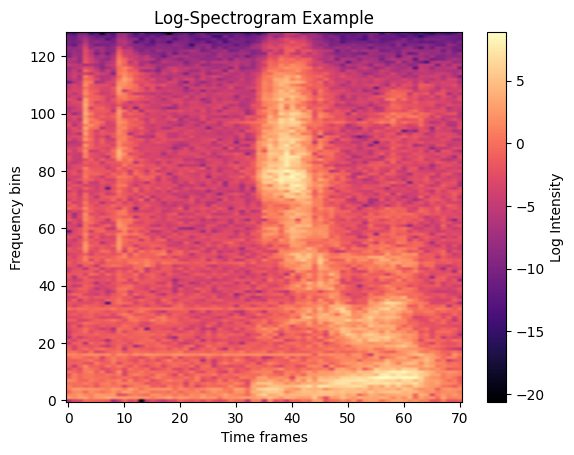

In [ ]:
X = np.load(drive_path + 'x_digits.npy')
y = np.load(drive_path + 'y_digits.npy')

plt.imshow(X[2], aspect='auto', origin='lower', cmap='magma')
plt.colorbar(label="Log Intensity")
plt.xlabel("Time frames")
plt.ylabel("Frequency bins")
plt.title("Log-Spectrogram Example")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)
X.shape, y.shape # num_samples, height (frequency bins), width (time steps)
y[0]

np.float64(0.0)

Fully connected network


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.optimizers import AdamW, Nadam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from copy import deepcopy

cat_loss = "sparse_categorical_crossentropy"

X_train_fc = X_train.reshape(X_train.shape[0], -1)
X_val_fc = X_val.reshape(X_val.shape[0], -1)
X_test_fc = X_test.reshape(X_test.shape[0], -1)

X_train_fc.shape, X_val_fc.shape, X_test_fc.shape

tf.random.set_seed(42)

X_train_fc[0].shape

(9159,)

In [ ]:
player1 = AdamW(learning_rate = 0.003, weight_decay = 0.002)
player2 = Nadam(learning_rate = 0.001, ema_momentum = 0.98) 

def evaluate_model(layers, X_train, y_train, X_val, y_val, optimizer=player1, epochs=30):

  model = Sequential(layers=deepcopy(layers))
  model.compile(loss="sparse_categorical_crossentropy", optimizer = deepcopy(optimizer), metrics=["accuracy"])
  earlyStopping = EarlyStopping(monitor = 'val_loss', patience = 7, restore_best_weights = True)
  learningRateCB = ReduceLROnPlateau(factor = 0.5, patience = 2)
  history = model.fit(X_train, y_train, epochs = epochs, validation_data=(X_val, y_val),callbacks = [earlyStopping,learningRateCB])

  return history

In [ ]:

idea1 = [
        Input(X_train_fc[0].shape),
        Dense(550, activation="relu", kernel_initializer = "he_normal"),
        Dropout(0.01),
        Dense(150, activation="relu", kernel_initializer = "he_normal"),
        Dropout(0.02),
        Dense(50, activation="leaky_relu", kernel_initializer = "he_normal"),
        Dense(10, activation="softmax")
    ]

idea2 =[
        Input(X_train[0].shape),
        Dense(500, activation="relu", kernel_initializer = "he_normal"),
        Dropout(0.2),
        Dense(250, activation="leaky_relu", kernel_initializer = "he_normal"),
        Dropout(0.1),
        Dense(100, activation="leaky_relu", kernel_initializer = "he_normal"),
        Flatten(),
        Dense(10, activation="softmax")
    ]


idea3 = [
        Input(X_train[0].shape),
        Dense(50, activation="relu", kernel_initializer = "he_normal"),
        Dropout(0.05),
        Dense(25, activation="leaky_relu", kernel_initializer = "he_normal"),
        Dropout(0.05),
        Dense(15, activation="leaky_relu", kernel_initializer = "he_normal"),
        Flatten(),
        Dense(10, activation="softmax")
    ]


In [ ]:
h1 = evaluate_model(idea1, X_train_fc, y_train, X_val_fc, y_val, epochs=120)

# h2 = evaluate_model(idea2, X_train, y_train, X_val, y_val)

Epoch 1/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.1229 - loss: 20.9354 - val_accuracy: 0.1302 - val_loss: 2.2854 - learning_rate: 0.0030
Epoch 2/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1171 - loss: 2.2904 - val_accuracy: 0.1312 - val_loss: 2.2628 - learning_rate: 0.0030
Epoch 3/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1252 - loss: 2.3251 - val_accuracy: 0.1186 - val_loss: 2.3073 - learning_rate: 0.0030
Epoch 4/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1173 - loss: 2.3045 - val_accuracy: 0.1152 - val_loss: 2.3112 - learning_rate: 0.0030
Epoch 5/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1095 - loss: 2.3030 - val_accuracy: 0.1249 - val_loss: 2.3283 - learning_rate: 0.0015
Epoch 6/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1174 - loss: 2.3013 - val_accuracy: 0.1173 - val_loss: 2.2923 - learning_rate: 0.0015
Epoch 7/120
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1107 - loss:

In [ ]:
h3 = evaluate_model(idea3, X_train, y_train, X_val, y_val)

Epoch 1/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3879 - loss: 2.7718 - val_accuracy: 0.6715 - val_loss: 1.0333 - learning_rate: 0.0030
Epoch 2/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7027 - loss: 0.9273 - val_accuracy: 0.7297 - val_loss: 0.8566 - learning_rate: 0.0030
Epoch 3/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7511 - loss: 0.7775 - val_accuracy: 0.7783 - val_loss: 0.6833 - learning_rate: 0.0030
Epoch 4/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7693 - loss: 0.7042 - val_accuracy: 0.7825 - val_loss: 0.6635 - learning_rate: 0.0030
Epoch 5/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7800 - loss: 0.6711 - val_accuracy: 0.7853 - val_loss: 0.6651 - learning_rate: 0.0030
Epoch 6/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7894 - loss: 0.6495 - val_accuracy: 0.7867 - val_loss: 0.6781 - learning_rate: 0.0030
Epoch 7/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8244 - loss: 0.5351 

In [ ]:


# h4 = evaluate_model(idea3, X_train, y_train, X_val, y_val, optimizer=player2)

In [ ]:
def display_sheet(history):
  train_losses = history.history['loss']
  val_losses = history.history['val_loss']
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  plt.figure(figsize=(10, 5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss over Epochs')
  plt.legend()
  plt.grid(True)
  plt.show()


  plt.figure(figsize=(10, 5))
  plt.plot(accuracy, label='Accuracy')
  plt.plot(val_accuracy, label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.title('Accuracy over epochs')
  plt.legend()
  plt.grid(True)
  plt.show()

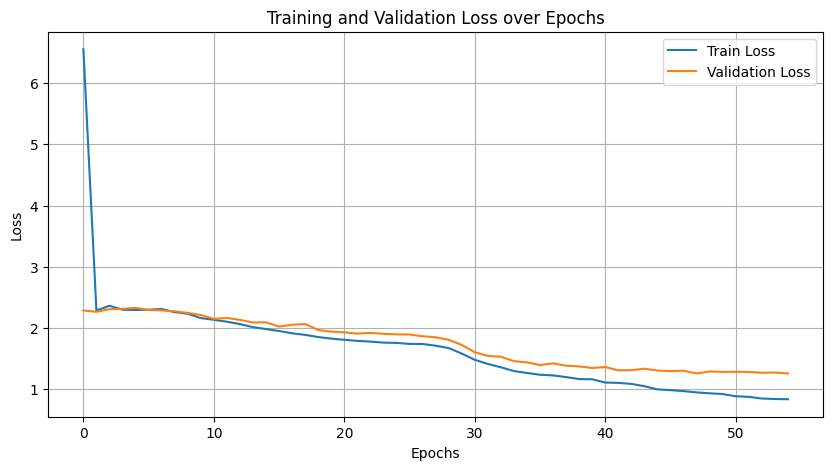

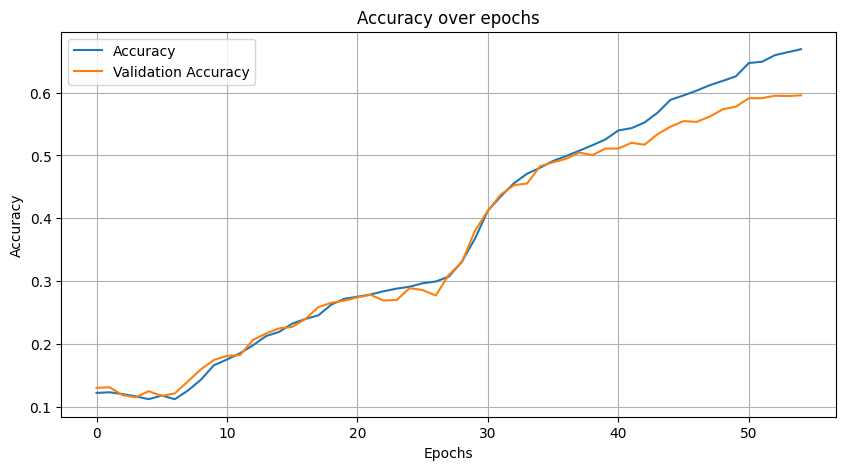

In [ ]:
display_sheet(h1)

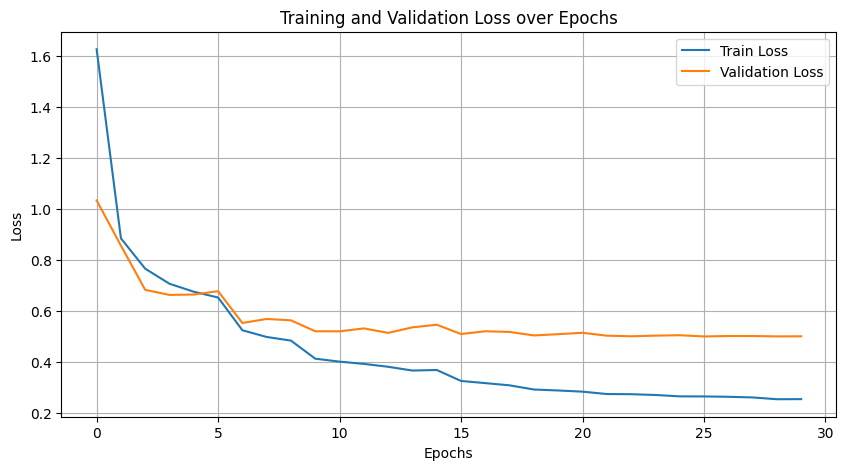

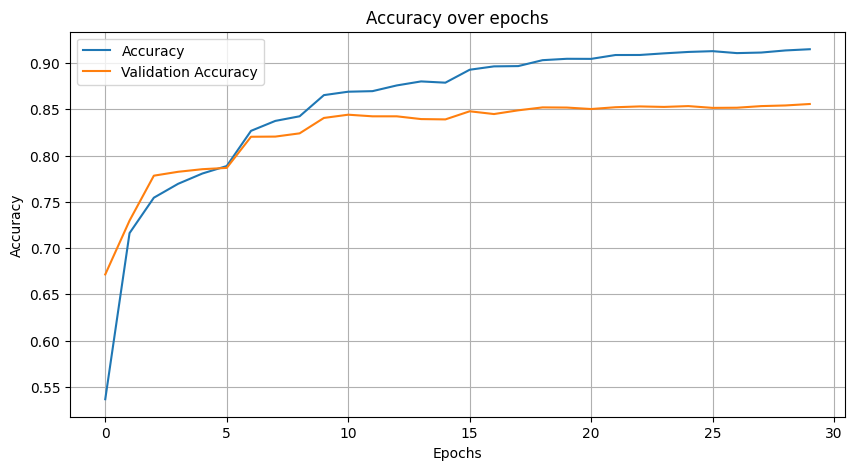

In [ ]:
display_sheet(h3)

CONVOLUTIONAL NETWORK


In [ ]:
X_train_cnn = X_train[..., np.newaxis] # adds channel dimension
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

In [ ]:
# tf.config.run_eagerly(True)
ideacnn = [
    Input(X_train_cnn[0].shape),
    Conv2D(16, (3,3), activation = "relu", kernel_initializer = "he_normal"),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(32, (3,3), activation = "relu", kernel_initializer = "he_normal"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(200, activation = "relu", kernel_initializer = "he_normal"),
    Dropout(0.2),
    Dense(200, activation = "relu", kernel_initializer = "he_normal"),
    Dense(10, activation = "softmax")
]

hcnn = evaluate_model(ideacnn, X_train_cnn, y_train, X_val_cnn, y_val)

Epoch 1/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.4646 - loss: 5.0541 - val_accuracy: 0.7786 - val_loss: 0.6645 - learning_rate: 0.0030
Epoch 2/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7658 - loss: 0.6982 - val_accuracy: 0.8227 - val_loss: 0.5465 - learning_rate: 0.0030
Epoch 3/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8106 - loss: 0.5636 - val_accuracy: 0.8444 - val_loss: 0.4695 - learning_rate: 0.0030
Epoch 4/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8426 - loss: 0.4761 - val_accuracy: 0.8486 - val_loss: 0.4823 - learning_rate: 0.0030
Epoch 5/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8529 - loss: 0.4403 - val_accuracy: 0.8337 - val_loss: 0.5047 - learning_rate: 0.0030
Epoch 6/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8899 - loss: 0.3215 - val_accuracy: 0.8744 - val_loss: 0.4082 - learning_rate: 0.0015
Epoch 7/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9161 - loss: 0.2415 

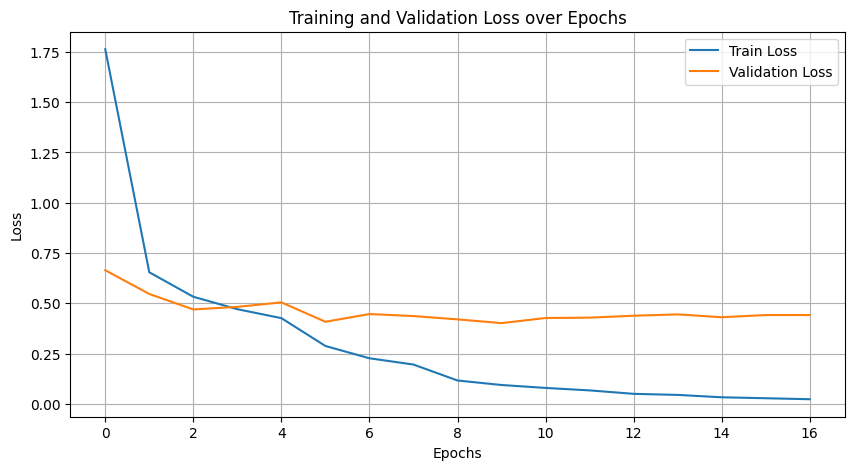

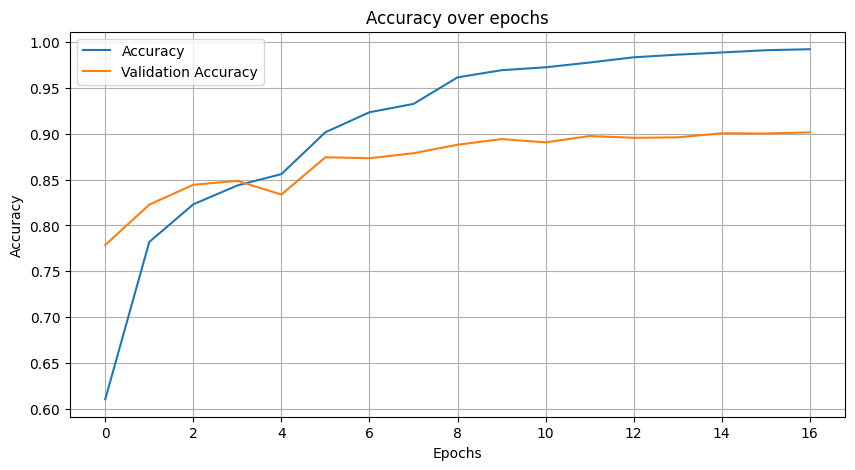

In [ ]:
display_sheet(hcnn)

In [ ]:
model = hcnn.model
print("Loss + accuracy on train data: {}".format(model.evaluate(X_train_cnn, y_train)))
print("Loss + accuracy on test data: {}".format(model.evaluate(X_test_cnn, y_test)))

713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9933 - loss: 0.0278
Loss + accuracy on train data: [0.0280267633497715, 0.9932464957237244]
223/223 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8846 - loss: 0.4331
Loss + accuracy on test data: [0.43604886531829834, 0.8842430114746094]


In [ ]:
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis = 1)

223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


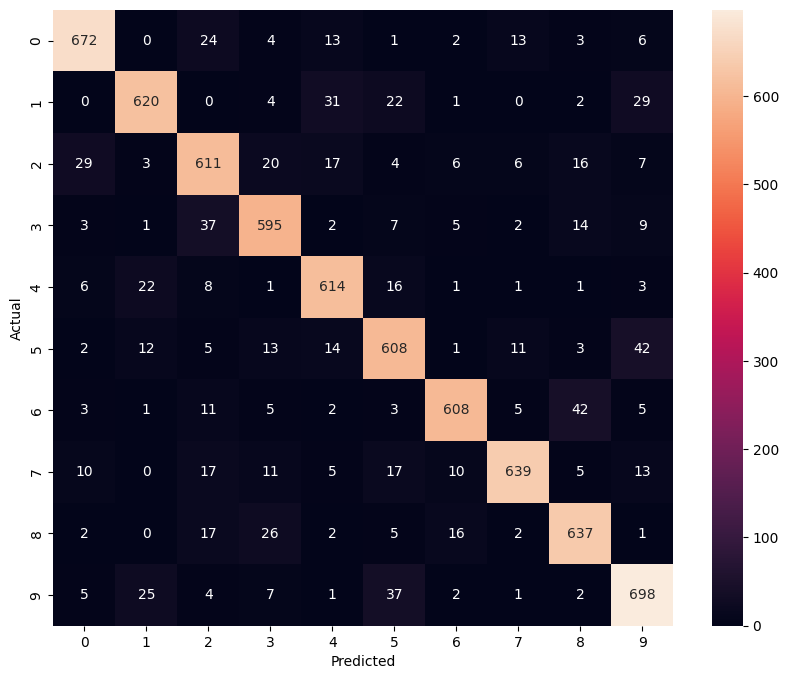

In [ ]:
# Confusion matrix
y_pred = np.argmax(model.predict(X_test_cnn), axis=1)
# y_true = np.concatenate([y for x, y in X_test_cnn], axis=0)
y_true = y_test
cm = tf.math.confusion_matrix(y_true, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()